In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import StratifiedKFold
from scipy import stats

In [3]:
users_df = pd.read_csv('features_data_with_dummies.csv')
users_df

,time_spent,first_deposit_amount,user_id,churned,risk_tolerance_high,risk_tolerance_low,risk_tolerance_medium,investment_experience_extensive,investment_experience_good,investment_experience_limited,...,trading_span,total_trades,time_per_trade,trades_per_day,max_daily_change,min_daily_change,max_daily_abs_change,mean_daily_change,balance_on_last_active_day,total_active_days
0,33.129417,40.0,895044c23edc821881e87da749c01034,0,1,0,0,0,0,1,...,364,190,0.174365,1.915789,79.22,-76.30,79.22,0.154909,81.22,190
1,16.573517,200.0,458b1d95441ced242949deefe8e4b638,0,0,0,1,0,0,1,...,364,252,0.065768,1.444444,385.92,-384.27,385.92,-0.858466,382.52,252
2,10.008367,25.0,c7936f653d293479e034865db9bb932f,0,0,0,1,0,0,1,...,364,252,0.039716,1.444444,40.24,-40.24,40.24,-0.110247,49.24,252
3,1.031633,100.0,b255d4bd6c9ba194d3a350b3e76c6393,0,0,0,1,0,0,1,...,364,143,0.007214,2.545455,203.14,-185.86,203.14,0.432598,190.87,143
4,8.187250,20.0,4a168225e89375b8de605cbc0977ae91,0,1,0,0,0,0,1,...,364,252,0.032489,1.444444,468.48,-463.73,468.48,0.285055,164.42,252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5579,8.339283,300.0,03880c726d8a4e5db006afe4119ad974,0,1,0,0,0,0,1,...,364,252,0.033092,1.444444,3087.72,-3087.56,3087.72,-6.295890,3022.58,252
5580,7.241383,100.0,ae8315109657f44852b24c6bca4decd6,1,0,0,1,0,0,1,...,364,99,0.073145,3.676768,618.27,-619.53,619.53,1.696723,504.84,99
5581,22.967167,50.0,f29c174989f9737058fe808fcf264135,0,0,0,1,0,0,0,...,364,197,0.116585,1.847716,449.21,-446.45,449.21,1.431568,451.61,197
5582,10.338417,100.0,24843497d1de88b2e7233f694436cb3a,0,0,0,1,0,0,1,...,364,141,0.073322,2.581560,365.25,-361.51,365.25,1.130850,321.88,141


In [15]:
# Four categories of columns that may be removed

# Dates of first and last trades
contenders_for_removal_1 = ['first_trade', 'last_trade']

# Time per trade and trade per day
contenders_for_removal_2 = ['time_per_trade', 'trades_per_day']

# Max/min/max abs/mean daily changes
contenders_for_removal_3 = ['max_daily_change', 'min_daily_change', 'max_daily_abs_change', 'mean_daily_change']

# Balance on last active day
contenders_for_removal_4 = ['balance_on_last_active_day']


# Drop columns
users_df = users_df.drop(columns=[c for c in contenders_for_removal_1 if c in users_df.contenders_for_removal_1])

NameError: name 'first_trade' is not defined

In [ ]:
# Convert data columns to

In [16]:
users_df.columns

Index(['time_spent', 'first_deposit_amount', 'user_id', 'churned',
       'risk_tolerance_high', 'risk_tolerance_low', 'risk_tolerance_medium',
       'investment_experience_extensive', 'investment_experience_good',
       'investment_experience_limited', 'investment_experience_none',
       'liquidity_needs_not_important', 'liquidity_needs_somewhat_important',
       'liquidity_needs_very_important', 'platform_Android', 'platform_both',
       'platform_iOS', 'instrument_type_first_traded_adr',
       'instrument_type_first_traded_etp', 'instrument_type_first_traded_mlp',
       'instrument_type_first_traded_other',
       'instrument_type_first_traded_reit',
       'instrument_type_first_traded_stock', 'time_horizon_long',
       'time_horizon_medium', 'time_horizon_short', 'first_trade',
       'last_trade', 'trading_span', 'total_trades', 'time_per_trade',
       'trades_per_day', 'max_daily_change', 'min_daily_change',
       'max_daily_abs_change', 'mean_daily_change',
       'ba

In [17]:
# Random Forest Classified
rfc = RandomForestClassifier(random_state=42)

# Features
X = users_df.drop(columns=['user_id', 'churned', 'first_trade', 'last_trade'])

# Target
y = users_df['churned']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [18]:
%%time

# Define two types of K-Fold Cross Validation strategies so that either one can be used
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define model
rfc = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],          
    'max_depth': [None, 10, 20, 30, 50, 100],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy'],
}

# Define GridSearchCV with KFold
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    cv=kf,
    scoring='precision',
    n_jobs=-1
)

# Fit on your training data
grid_search.fit(X_train, y_train)

# Best model
#best_model = grid_search.best_estimator_
rfc_best = grid_search.best_estimator_
rfc_best.fit(X_train, y_train)

KeyboardInterrupt: 

# Bypassing K-Fold just to have results for now. Stratified KFold

In [4]:
# Random Forest Classified
rfc = RandomForestClassifier(random_state=42)

# Features
X = users_df.drop(columns=['user_id', 'churned', 'first_trade', 'last_trade'])

# Target
y = users_df['churned']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [8]:
from sklearn.model_selection import cross_val_predict


# Define two types of K-Fold Cross Validation strategies so that either one can be used
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Generate out-of-fold predictions for all data
y_pred_all = cross_val_predict(rfc, X, y, cv=skf)


# Get predicted probabilities
y_proba_all = cross_val_predict(rfc, X, y, cv=skf, method='predict_proba')

# Regular predictions
y_pred_all = cross_val_predict(rfc, X, y, cv=skf)


# If binary classification, pick the probability of the predicted class
# (confidence in whichever class was chosen)
y_pred_indices = np.array([list(np.unique(y)).index(p) for p in y_pred_all])
confidence_scores = y_proba_all[np.arange(len(y_proba_all)), y_pred_indices]

# Build results dataframe
rfc_cv_results = pd.DataFrame()
rfc_cv_results['user_id'] = users_df['user_id']
rfc_cv_results['churned'] = y
rfc_cv_results['Prediction'] = y_pred_all
rfc_cv_results['Prediction Correct'] = (rfc_cv_results['churned'] == rfc_cv_results['Prediction']).astype(int)
rfc_cv_results['Prediction Confidence'] = confidence_scores

#df['percentage_of_max'] = (df['values'] / max_value) * 100

rfc_cv_results

,user_id,churned,Prediction,Prediction Correct,Prediction Confidence
0,895044c23edc821881e87da749c01034,0,0,1,0.81
1,458b1d95441ced242949deefe8e4b638,0,0,1,1.00
2,c7936f653d293479e034865db9bb932f,0,0,1,1.00
3,b255d4bd6c9ba194d3a350b3e76c6393,0,0,1,0.93
4,4a168225e89375b8de605cbc0977ae91,0,0,1,1.00
...,...,...,...,...,...
5579,03880c726d8a4e5db006afe4119ad974,0,0,1,1.00
5580,ae8315109657f44852b24c6bca4decd6,1,1,1,0.86
5581,f29c174989f9737058fe808fcf264135,0,0,1,0.76
5582,24843497d1de88b2e7233f694436cb3a,0,0,1,0.95


Accuracy : 0.9269 [TP / N]         Best: 1, Worst: 0
           Percentage of all predictions that were correct.
Precision: 0.8672 [TP / (TP + FP)] Best: 1, Worst: 0
           Percent of Positive predictions that were correct. Minimizes false positives.
Recall   : 0.7015 [TP / (TP + FN)] Best: 1, Worst: 0
           Percent of Positive instances that were identified as such. Minimizes false negatives.
F1 Score : 0.7756 [2PR / (P + R)]  Best: 1, Worst: 0
           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.
ROC AUC  : 0.8390                  Best: 1, Worst: < 0.5
--------------------------------------------------------------------------------
TP: True Positives, FP: False Positives,
TN: True Negatives, FN: False Negatives,
N: Number of samples


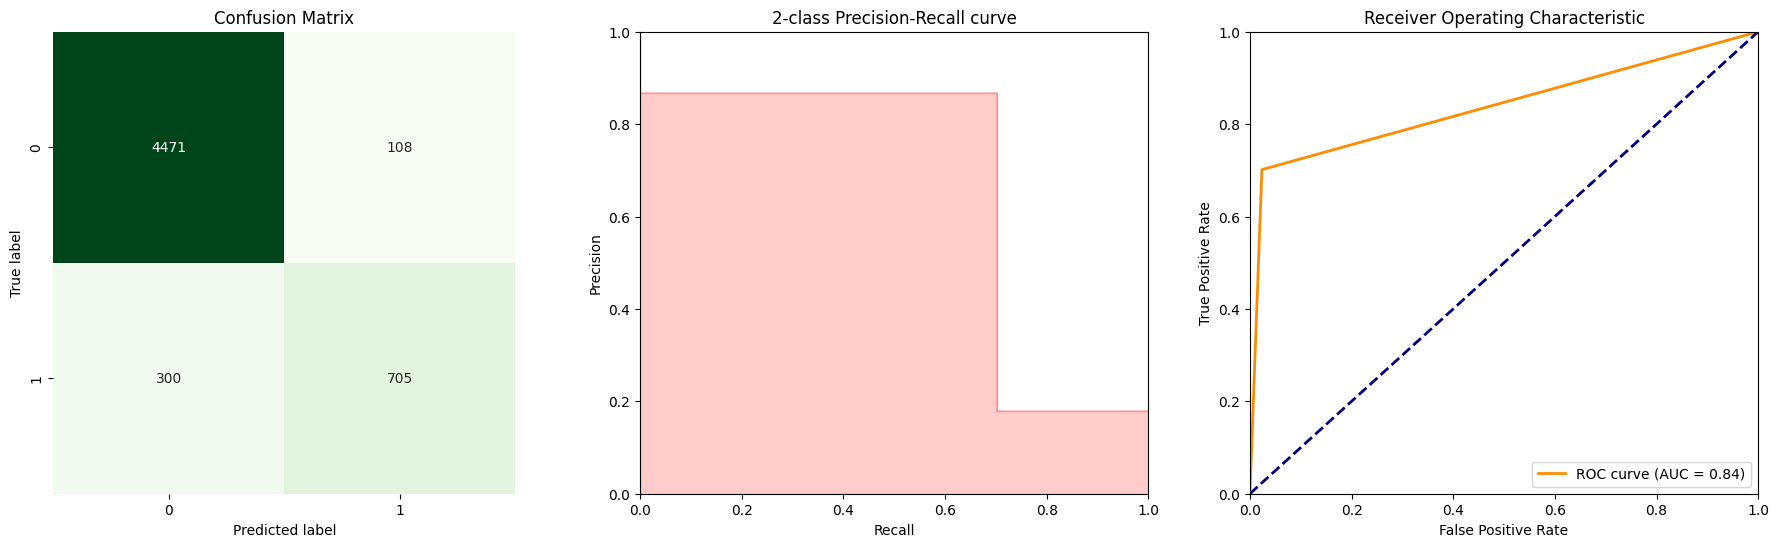

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, precision_recall_curve, roc_curve, auc, f1_score
)

def show_summary_report(actual, prediction):
    if isinstance(actual, pd.Series):
        actual = actual.values.astype(int)
    prediction = prediction.astype(float)
    prediction_int = np.round(prediction)

    print('Accuracy : %.4f [TP / N]         Best: 1, Worst: 0' %
          accuracy_score(actual, prediction_int))
    print('           Percentage of all predictions that were correct.')

    print('Precision: %.4f [TP / (TP + FP)] Best: 1, Worst: 0' %
          precision_score(actual, prediction_int))
    print('           Percent of Positive predictions that were correct. Minimizes false positives.')

    print('Recall   : %.4f [TP / (TP + FN)] Best: 1, Worst: 0' %
          recall_score(actual, prediction_int))
    print('           Percent of Positive instances that were identified as such. Minimizes false negatives.')

    print('F1 Score : %.4f [2PR / (P + R)]  Best: 1, Worst: 0' %
          f1_score(actual, prediction_int))
    print('           Harmonic mean of Precision and Recall. Strives to find a balance in minimizing both.')

    print('ROC AUC  : %.4f                  Best: 1, Worst: < 0.5' %
          roc_auc_score(actual, prediction))

    print('-' * 80)
    print('TP: True Positives, FP: False Positives,')
    print('TN: True Negatives, FN: False Negatives,')
    print('N: Number of samples')

    # Confusion Matrix
    mat = confusion_matrix(actual, prediction_int, labels=[0, 1])

    # Precision/Recall
    precision, recall, _ = precision_recall_curve(actual, prediction)

    # Compute ROC curve and ROC area
    fpr, tpr, _ = roc_curve(actual, prediction)
    roc_auc = auc(fpr, tpr)

    # plot
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.subplots_adjust(left=0.02, right=0.98, wspace=0.2)

    # Confusion Matrix (no .T)
    sns.heatmap(mat, square=True, annot=True, fmt='d',
                cbar=False, cmap='Greens', ax=ax[0])
    ax[0].set_title('Confusion Matrix')
    ax[0].set_xlabel('Predicted label')
    ax[0].set_ylabel('True label')

    # Precision/Recall
    step_kwargs = {'step': 'post'}
    ax[1].step(recall, precision, color='r', alpha=0.2, where='post')
    ax[1].fill_between(recall, precision, alpha=0.2, color='r', **step_kwargs)
    ax[1].set_ylim([0.0, 1.0])
    ax[1].set_xlim([0.0, 1.0])
    ax[1].set_xlabel('Recall')
    ax[1].set_ylabel('Precision')
    ax[1].set_title('2-class Precision-Recall curve')

    # ROC
    ax[2].plot(fpr, tpr, color='darkorange', lw=2,
               label='ROC curve (AUC = %0.2f)' % roc_auc)
    ax[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[2].set_xlim([0.0, 1.0])
    ax[2].set_ylim([0.0, 1.0])
    ax[2].set_xlabel('False Positive Rate')
    ax[2].set_ylabel('True Positive Rate')
    ax[2].set_title('Receiver Operating Characteristic')
    ax[2].legend(loc='lower right')

    plt.show()


show_summary_report(y, y_pred_all)